<a href="https://colab.research.google.com/github/OmniGrid7/Movie-Review-Sentiment-Analysis/blob/main/Movie_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Review Sentiment Analysis




## 1. Setup

In [7]:
!pip install -q transformers datasets evaluate accelerate lime wordcloud


In [8]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from datasets import load_dataset
import evaluate

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)


In [9]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if not torch.cuda.is_available():
    print("no GPU - go to Runtime > Change runtime type > GPU")


cuda


In [10]:
os.makedirs("data", exist_ok=True)
os.makedirs("models/bert_sentiment_model", exist_ok=True)
os.makedirs("models/tokenizer", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


## 2. Load data

IMDb dataset from Hugging Face's `datasets` lib. Full set is 25k/25k train/test, balanced. We just take a smaller balanced chunk of it.


In [6]:
imdb = load_dataset("mteb/imdb")
imdb


README.md:   0%|          | 0.00/6.99k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.9MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.2MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/24904 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24678 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 24904
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 24678
    })
})

In [11]:
type(imdb)


datasets.dataset_dict.DatasetDict

In [12]:
imdb["train"][0]


{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [13]:
imdb["train"].features


{'text': Value('string'),
 'label': Value('int64'),
 'label_text': Value('string')}

In [14]:
TRAIN_SIZE = 4000
VAL_SIZE = 1000
TEST_SIZE = 1000

def balanced_subset(split, n_total, seed=SEED):
    df = split.to_pandas()
    n = n_total // 2
    pos = df[df.label == 1].sample(n=n, random_state=seed)
    neg = df[df.label == 0].sample(n=n, random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)

train_val_df = balanced_subset(imdb["train"], TRAIN_SIZE + VAL_SIZE)
test_df = balanced_subset(imdb["test"], TEST_SIZE)

train_df = train_val_df.iloc[:TRAIN_SIZE].reset_index(drop=True)
val_df = train_val_df.iloc[TRAIN_SIZE:].reset_index(drop=True)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()


(4000, 3) (1000, 3) (1000, 3)


,text,label,label_text
0,all the acting done in the first season has be...,1,positive
1,Remember the chain-smoking channeler exposed o...,0,negative
2,Christ. A sequel to one of the most cloying fi...,0,negative
3,I originally caught this back in 1996 in its o...,1,positive
4,"good movie, good music, good background and an...",1,positive


In [15]:
train_df.shape


(4000, 3)

In [16]:
train_df.columns


Index(['text', 'label', 'label_text'], dtype='object')

In [17]:
type(train_df)


pandas.core.frame.DataFrame

In [18]:
pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val"),
    test_df.assign(split="test"),
]).to_csv("data/imdb_dataset.csv", index=False)


In [19]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, df.label.value_counts().to_dict())


train {1: 2025, 0: 1975}
val {0: 525, 1: 475}
test {0: 500, 1: 500}


## 3. A quick look at the data

In [20]:
train_df.isnull().sum()


,0
text,0
label,0
label_text,0


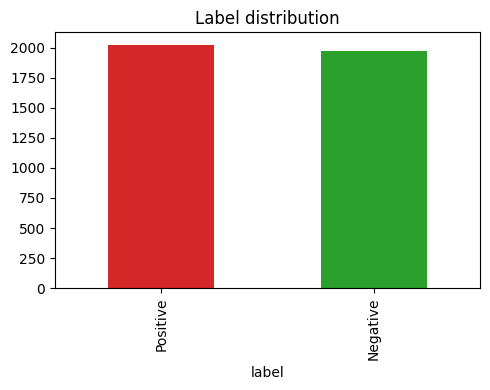

In [21]:
train_df.label.map({0: "Negative", 1: "Positive"}).value_counts().plot(
    kind="bar", color=["#d62728", "#2ca02c"], figsize=(5, 4), title="Label distribution"
)
plt.tight_layout()
plt.savefig("outputs/label_distribution.png")
plt.show()


In [22]:
train_df["word_count"] = train_df["text"].apply(lambda x: len(x.split()))
train_df["word_count"].describe()


,word_count
count,4000.000000
mean,232.964000
std,170.994178
min,18.000000
25%,126.000000
50%,173.000000
75%,287.250000
max,1839.000000


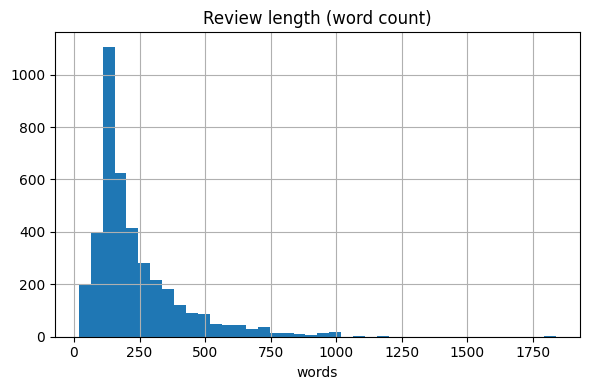

In [23]:
train_df["word_count"].hist(bins=40, figsize=(6, 4), color="#1f77b4")
plt.title("Review length (word count)")
plt.xlabel("words")
plt.tight_layout()
plt.savefig("outputs/review_length_histogram.png")
plt.show()


In [24]:
from collections import Counter
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def words_only(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    return [w for w in text.lower().split() if w not in stop_words and len(w) > 2]

all_words = []
for t in train_df["text"].sample(min(1000, len(train_df)), random_state=SEED):
    all_words.extend(words_only(t))

word_freq = Counter(all_words)
word_freq.most_common(20)


[('movie', 1804),
 ('film', 1665),
 ('one', 1155),
 ('like', 789),
 ('good', 617),
 ('would', 555),
 ('time', 529),
 ('even', 527),
 ('see', 478),
 ('really', 475),
 ('story', 473),
 ('well', 463),
 ('people', 415),
 ('much', 405),
 ('get', 389),
 ('also', 388),
 ('great', 385),
 ('made', 382),
 ('bad', 376),
 ('first', 360)]

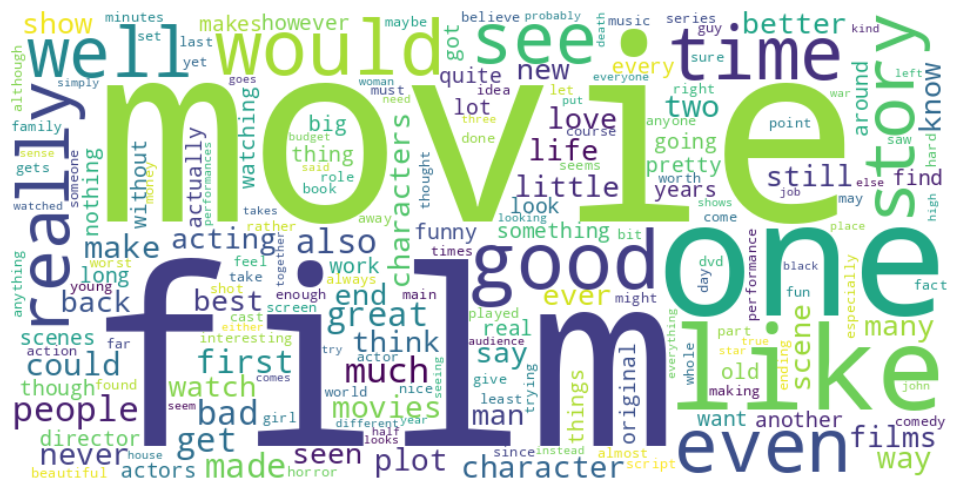

In [25]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig("outputs/wordcloud.png")
plt.show()


## 4. Cleaning

BERT does its own tokenization so there's not much to do here - just strip the leftover HTML from the IMDb scrape (`<br />` tags show up a lot) and normalize whitespace. Not removing stopwords or lowercasing manually since `bert-base-uncased` handles that and punctuation/casing actually carry signal for it.


In [26]:
def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

train_df["clean_text"].iloc[0][:300]


'all the acting done in the first season has been really amazing. the first look you get of Max and Zach is through Geneva Locke and Chris Lazar or as i like to call them the minis. the minis do the best acting job that i have ever seen kids do. the main actors and actresses i.e. Jessica Alba Michael'

## 5. Tokenization

In [27]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256  # most reviews fit fine, and it's a lot faster than 512

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

enc = tokenizer(train_df["clean_text"].iloc[0], truncation=True, max_length=MAX_LENGTH, padding="max_length")
tokenizer.decode(enc["input_ids"][:20])


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

'[CLS] all the acting done in the first season has been really amazing. the first look you get of'

In [28]:
type(enc)


transformers.tokenization_utils_base.BatchEncoding

In [29]:
enc.keys()


KeysView({'input_ids': [101, 2035, 1996, 3772, 2589, 1999, 1996, 2034, 2161, 2038, 2042, 2428, 6429, 1012, 1996, 2034, 2298, 2017, 2131, 1997, 4098, 1998, 12397, 2003, 2083, 9810, 18343, 1998, 3782, 2474, 9057, 2030, 2004, 1045, 2066, 2000, 2655, 2068, 1996, 7163, 2015, 1012, 1996, 7163, 2015, 2079, 1996, 2190, 3772, 3105, 2008, 1045, 2031, 2412, 2464, 4268, 2079, 1012, 1996, 2364, 5889, 1998, 19910, 1045, 1012, 1041, 1012, 8201, 18255, 2745, 4633, 2135, 4385, 1012, 2191, 2017, 5293, 2017, 2024, 3666, 1037, 7214, 1056, 1012, 1058, 1012, 2265, 2027, 4025, 2000, 2191, 2023, 2265, 2272, 4142, 1012, 2035, 1999, 2035, 2023, 2003, 1996, 2190, 2265, 1045, 2031, 2412, 3427, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [30]:
len(enc["input_ids"])


256

In [31]:
class IMDbDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = IMDbDataset(train_df["clean_text"], train_df["label"], tokenizer)
val_dataset = IMDbDataset(val_df["clean_text"], val_df["label"], tokenizer)
test_dataset = IMDbDataset(test_df["clean_text"], test_df["label"], tokenizer)

len(train_dataset), len(val_dataset), len(test_dataset)


(4000, 1000, 1000)

## 6. Fine-tuning BERT

Using the HF `Trainer` instead of writing the training loop by hand - it takes care of the optimizer, LR schedule, and mixed precision for us.


In [32]:
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [33]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"],
    }


In [34]:
training_args = TrainingArguments(
    output_dir="outputs/checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=25,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer),
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [35]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.310386,0.310499,0.880000,0.878788
2,0.136768,0.345064,0.891000,0.889788
3,0.118159,0.412602,0.899000,0.895337


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=750, training_loss=0.24094359429677328, metrics={'train_runtime': 249.4146, 'train_samples_per_second': 48.113, 'train_steps_per_second': 3.007, 'total_flos': 1578666332160000.0, 'train_loss': 0.24094359429677328, 'epoch': 3.0})

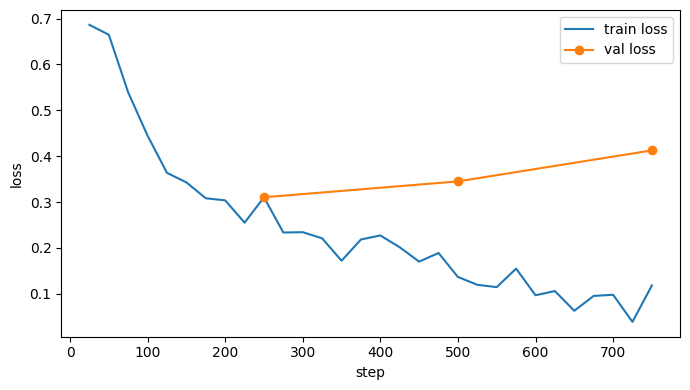

In [36]:
log_history = trainer.state.log_history
train_loss = [(x["step"], x["loss"]) for x in log_history if "loss" in x]
eval_loss = [(x["step"], x["eval_loss"]) for x in log_history if "eval_loss" in x]

plt.figure(figsize=(7, 4))
if train_loss:
    s, l = zip(*train_loss)
    plt.plot(s, l, label="train loss")
if eval_loss:
    s, l = zip(*eval_loss)
    plt.plot(s, l, label="val loss", marker="o")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/training_loss.png")
plt.show()


## 7. Evaluation

In [37]:
test_output = trainer.predict(test_dataset)
test_logits = test_output.predictions
test_labels = test_output.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_preds = np.argmax(test_logits, axis=-1)


In [38]:
acc = accuracy_score(test_labels, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average="binary")
try:
    auc = roc_auc_score(test_labels, test_probs[:, 1])
except Exception:
    auc = float("nan")

report = f"Accuracy : {acc:.4f}\nPrecision: {precision:.4f}\nRecall   : {recall:.4f}\nF1-score : {f1:.4f}\nROC-AUC  : {auc:.4f}"
print(report)

with open("outputs/evaluation_report.txt", "w") as f:
    f.write(report)


Accuracy : 0.9030
Precision: 0.8913
Recall   : 0.9180
F1-score : 0.9044
ROC-AUC  : 0.9677


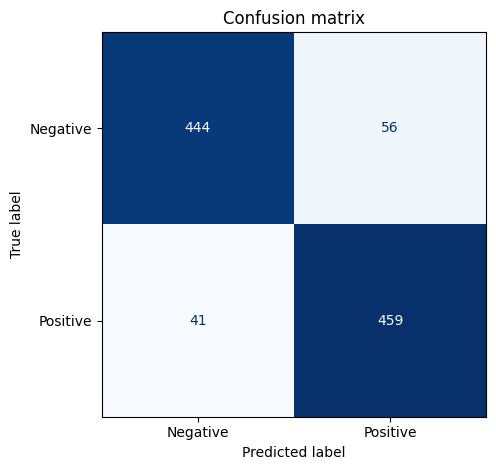

In [39]:
cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png")
plt.show()


## 8. Try it on your own text

In [40]:
model.eval()

def predict_sentiment(text, max_length=MAX_LENGTH):
    clean = clean_text(text)
    enc = tokenizer(clean, truncation=True, max_length=max_length, padding="max_length", return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    label = "Positive" if probs[1] > probs[0] else "Negative"
    return label, float(max(probs))

sample_reviews = [
    "This movie was an absolute masterpiece, the acting and story blew me away!",
    "Waste of two hours. Poor script, worse acting, and a pointless plot.",
    "It was okay, some good moments but overall pretty forgettable.",
]

for r in sample_reviews:
    label, conf = predict_sentiment(r)
    print(f"{label} ({conf:.1%}) - {r}")


Positive (99.6%) - This movie was an absolute masterpiece, the acting and story blew me away!
Negative (99.2%) - Waste of two hours. Poor script, worse acting, and a pointless plot.
Negative (96.2%) - It was okay, some good moments but overall pretty forgettable.


In [41]:
review = input("Enter a review: ")
label, conf = predict_sentiment(review)
print(f"{label} ({conf:.1%})")


Enter a review: This movie was absolutely brilliant, the performances were outstanding and the story kept me hooked from start to finish.
Positive (99.6%)


## 9. Save the model

In [42]:
MODEL_DIR = "models/bert_sentiment_model"
TOKENIZER_DIR = "models/tokenizer"

model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(TOKENIZER_DIR)
print("saved")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved


In [43]:
!zip -r -q models.zip models
!zip -r -q outputs.zip outputs
# from google.colab import files
# files.download('models.zip')


## 10. Load it back

In [44]:
loaded_tokenizer = BertTokenizerFast.from_pretrained(TOKENIZER_DIR)
loaded_model = BertForSequenceClassification.from_pretrained(MODEL_DIR)
loaded_model.to(device)
loaded_model.eval()

def predict_loaded(text, max_length=MAX_LENGTH):
    clean = clean_text(text)
    enc = loaded_tokenizer(clean, truncation=True, max_length=max_length, padding="max_length", return_tensors="pt").to(device)
    with torch.no_grad():
        logits = loaded_model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    label = "Positive" if probs[1] > probs[0] else "Negative"
    return label, float(max(probs))

for r in sample_reviews:
    label, conf = predict_loaded(r)
    print(f"{label} ({conf:.1%}) - {r}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Positive (99.6%) - This movie was an absolute masterpiece, the acting and story blew me away!
Negative (99.2%) - Waste of two hours. Poor script, worse acting, and a pointless plot.
Negative (96.2%) - It was okay, some good moments but overall pretty forgettable.


## 11. Why did it predict that?

Using LIME to see which words in a review pushed the prediction one way or the other.


In [45]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=["Negative", "Positive"])

def lime_predict_proba(texts):
    out = []
    for t in texts:
        clean = clean_text(t)
        enc = tokenizer(clean, truncation=True, max_length=MAX_LENGTH, padding="max_length", return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        out.append(probs)
    return np.array(out)

exp = explainer.explain_instance(sample_reviews[0], lime_predict_proba, num_features=10, num_samples=200)
exp.as_list()


[(np.str_('me'), 0.44987385854097933),
 (np.str_('masterpiece'), 0.28846906403673667),
 (np.str_('blew'), -0.19506691382104613),
 (np.str_('away'), -0.1672910340788873),
 (np.str_('absolute'), 0.11225169926871632),
 (np.str_('acting'), -0.08588322991189204),
 (np.str_('story'), -0.08067640140669205),
 (np.str_('This'), 0.0791148818598421),
 (np.str_('an'), -0.07271603143345286),
 (np.str_('movie'), -0.06619490138257647)]

In [46]:
exp.show_in_notebook(text=True)


## 12. Agentic movie recommendation system

Now we build a small agent-based system on top of the sentiment model above. Instead of one function doing everything, we give an LLM a set of tools and let it decide which ones to call, in what order, to answer a movie request.

```
user query -> agent (with tools: search, sentiment lookup, details) -> recommendations -> critic pass
```

- **search_movies** - a tool that filters the movie database by genre / rating / year
- **analyze_review_sentiment** - a tool that runs the BERT model we trained earlier on a movie's reviews
- **get_movie_details** - a tool that returns full metadata for a title
- the **agent** decides which tools to call based on the user's natural language query (this covers preference extraction, search, and ranking in one step)
- a separate **critic** call at the end checks whether the recommendations actually match the request

LLM backend here is **Groq** (`ChatGroq`), following the same pattern as the research paper notebook.


In [47]:
!pip install -U langchain langchain-community langchain-groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.13
    Uninstalling langchain-1.3.13:
      Successfully uninstalled langchain-1.3.13
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requi

In [48]:
from langchain_groq import ChatGroq


**API key.** Paste your Groq key below, or leave it blank and it'll try Colab's secret manager first, then fall back to a prompt. Rename `GROQ_API_KEY` to whatever you like, just keep it consistent below.


In [49]:
GROQ_API_KEY = ""

if not GROQ_API_KEY:
    try:
        from google.colab import userdata
        GROQ_API_KEY = userdata.get("GROQ_API_KEY")
    except Exception:
        pass

if not GROQ_API_KEY:
    import getpass
    GROQ_API_KEY = getpass.getpass("Enter your Groq API key: ")


In [50]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=GROQ_API_KEY,
    temperature=0,
)

llm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7f714d7ca390>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f714d7de150>, model_name='llama-3.1-8b-instant', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [51]:
response = llm.invoke("Hello, who are you?")
response


AIMessage(content="I'm an artificial intelligence model known as a large language model (LLM) or conversational AI. I'm a computer program designed to understand and respond to human language in a way that's natural and helpful.\n\nI don't have a personal identity or emotions like humans do, but I'm here to assist you with any questions, topics, or tasks you'd like to discuss. I can provide information, answer questions, generate text, and even engage in conversation.\n\nI'm constantly learning and improving my responses based on the conversations I have with users like you. So, feel free to ask me anything, and I'll do my best to help!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 41, 'total_tokens': 173, 'completion_time': 0.151401077, 'completion_tokens_details': None, 'prompt_time': 0.001924814, 'prompt_tokens_details': None, 'queue_time': 0.059703455, 'total_time': 0.153325891}, 'model_name': 'llama-3.1-8b-instant', 'system_f

In [52]:
response.content


"I'm an artificial intelligence model known as a large language model (LLM) or conversational AI. I'm a computer program designed to understand and respond to human language in a way that's natural and helpful.\n\nI don't have a personal identity or emotions like humans do, but I'm here to assist you with any questions, topics, or tasks you'd like to discuss. I can provide information, answer questions, generate text, and even engage in conversation.\n\nI'm constantly learning and improving my responses based on the conversations I have with users like you. So, feel free to ask me anything, and I'll do my best to help!"

In [53]:
print(type(response))


<class 'langchain_core.messages.ai.AIMessage'>


### A small movie database

Same demo dataset as before - a real project would swap this for a TMDB/OMDb call, the tools below don't care where the data comes from.

In [54]:
movie_db = [
    {
        "title": "Silent Fracture", "year": 2019, "genre": ["Psychological Thriller", "Drama"],
        "imdb_rating": 8.4, "story_type": "dark, twist-driven", "acting_quality": "excellent",
        "description": "A therapist starts to suspect her new patient is hiding something about an unsolved disappearance.",
        "reviews": [
            "The lead performance is chilling, one of the best psychological thrillers in years.",
            "Slow in the middle but the final twenty minutes are devastating and brilliantly acted.",
            "Dark, tense, and genuinely unsettling. The acting carries the whole film.",
        ],
    },
    {
        "title": "The Quiet Patient", "year": 2021, "genre": ["Psychological Thriller", "Mystery"],
        "imdb_rating": 8.1, "story_type": "dark, character study",
        "acting_quality": "excellent",
        "description": "A woman's silence after a violent crime becomes the center of a criminal investigation.",
        "reviews": [
            "Incredible central performance, restrained and haunting.",
            "The story unfolds slowly but the payoff is worth it. Dark and gripping.",
            "A masterclass in tension. Acting is top tier from start to finish.",
        ],
    },
    {
        "title": "Neon Skyline", "year": 2022, "genre": ["Action", "Sci-Fi"],
        "imdb_rating": 7.2, "story_type": "fast-paced, plot-driven",
        "acting_quality": "good",
        "description": "A courier in a near-future city gets caught between two rival corporations.",
        "reviews": [
            "Great visuals, fun action, but the story is pretty thin.",
            "Enjoyable popcorn sci-fi. Not deep, but a good time.",
            "The acting is fine, nothing special, but the action sequences are excellent.",
        ],
    },
    {
        "title": "Last Light in Marrow Creek", "year": 2018, "genre": ["Horror", "Psychological Thriller"],
        "imdb_rating": 7.8, "story_type": "dark, atmospheric",
        "acting_quality": "very good",
        "description": "A family moves into a house with a history, and the mother starts losing her grip on reality.",
        "reviews": [
            "More psychological than jump-scare horror, and it's better for it.",
            "Genuinely creepy, strong lead performance, dark tone throughout.",
            "A bit slow but the atmosphere and acting make up for it.",
        ],
    },
    {
        "title": "Coffee and Static", "year": 2020, "genre": ["Comedy", "Romance"],
        "imdb_rating": 6.9, "story_type": "light, feel-good",
        "acting_quality": "good",
        "description": "Two strangers keep running into each other at the same cafe over the course of a year.",
        "reviews": [
            "Charming and light, exactly what it sets out to be.",
            "Nothing groundbreaking but a pleasant, easy watch.",
            "Good chemistry between the leads, funny in places.",
        ],
    },
    {
        "title": "Hollow Verdict", "year": 2023, "genre": ["Psychological Thriller", "Crime"],
        "imdb_rating": 8.6, "story_type": "dark, morally complex",
        "acting_quality": "excellent",
        "description": "A defense attorney realizes her client's confession doesn't match the evidence, and neither does her own memory of that night.",
        "reviews": [
            "Easily one of the best thrillers of the year, the lead actor is phenomenal.",
            "Dense, dark, and demands your full attention. Worth it.",
            "The performances are outstanding, especially in the courtroom scenes.",
        ],
    },
    {
        "title": "Field Notes", "year": 2017, "genre": ["Documentary-style Drama"],
        "imdb_rating": 7.0, "story_type": "slow, reflective",
        "acting_quality": "good",
        "description": "A fictionalized account of a small town's last farming season before a factory buyout.",
        "reviews": [
            "Quiet and thoughtful, not for everyone but well made.",
            "Understated acting, realistic and grounded.",
            "A slow burn, more mood than plot.",
        ],
    },
    {
        "title": "Ashfall", "year": 2016, "genre": ["Action", "Thriller"],
        "imdb_rating": 6.5, "story_type": "fast-paced, plot-driven",
        "acting_quality": "average",
        "description": "A volcanologist and a demolition expert race to stop a chain of eruptions from reaching the capital.",
        "reviews": [
            "Fun disaster movie, doesn't take itself too seriously.",
            "The acting is a bit wooden but the effects are solid.",
            "Decent popcorn thriller, forgettable but entertaining.",
        ],
    },
    {
        "title": "Recursion", "year": 2024, "genre": ["Psychological Thriller", "Sci-Fi"],
        "imdb_rating": 8.3, "story_type": "dark, mind-bending",
        "acting_quality": "excellent",
        "description": "A memory scientist discovers her own recorded memories don't match her life anymore.",
        "reviews": [
            "Mind-bending in the best way, and the lead sells every second of it.",
            "Dark, smart, and the acting keeps it grounded even when the plot gets strange.",
            "One of the more original thrillers in a while. Excellent performances.",
        ],
    },
    {
        "title": "Paper Lanterns", "year": 2021, "genre": ["Drama", "Family"],
        "imdb_rating": 7.4, "story_type": "warm, emotional",
        "acting_quality": "very good",
        "description": "Three siblings return home to settle their late father's estate and old grudges.",
        "reviews": [
            "Emotional without being manipulative, strong ensemble cast.",
            "Made me cry more than once. Great performances all around.",
            "A little predictable but genuinely moving.",
        ],
    },
]

len(movie_db)


10

In [55]:
movie_db[0]


{'title': 'Silent Fracture',
 'year': 2019,
 'genre': ['Psychological Thriller', 'Drama'],
 'imdb_rating': 8.4,
 'story_type': 'dark, twist-driven',
 'acting_quality': 'excellent',
 'description': 'A therapist starts to suspect her new patient is hiding something about an unsolved disappearance.',
 'reviews': ['The lead performance is chilling, one of the best psychological thrillers in years.',
  'Slow in the middle but the final twenty minutes are devastating and brilliantly acted.',
  'Dark, tense, and genuinely unsettling. The acting carries the whole film.']}

In [56]:
type(movie_db)


list

### Tool 1: search_movies

In [57]:
from langchain_core.tools import tool

@tool
def search_movies(genre: str = "", min_rating: float = 0.0, year_from: int = 0, year_to: int = 9999) -> str:
    """
    Search the movie database for movies matching a genre, a minimum IMDb rating,
    and a release year range. Leave a field blank/0 to not filter on it.
    Returns a list of matching titles with year, genre, and rating.
    """
    results = []
    for movie in movie_db:
        if movie["imdb_rating"] < min_rating:
            continue
        if movie["year"] < year_from or movie["year"] > year_to:
            continue
        if genre and not any(genre.lower() in g.lower() for g in movie["genre"]):
            continue
        results.append(movie)

    if not results:
        return "No movies matched those filters."

    lines = [
        f"{m['title']} ({m['year']}) - {', '.join(m['genre'])} - rating {m['imdb_rating']}"
        for m in results
    ]
    return "\n".join(lines)


In [58]:
search_movies.invoke({"genre": "Psychological Thriller", "min_rating": 8.0})


'Silent Fracture (2019) - Psychological Thriller, Drama - rating 8.4\nThe Quiet Patient (2021) - Psychological Thriller, Mystery - rating 8.1\nHollow Verdict (2023) - Psychological Thriller, Crime - rating 8.6\nRecursion (2024) - Psychological Thriller, Sci-Fi - rating 8.3'

In [59]:
type(search_movies)


langchain_core.tools.structured.StructuredTool

### Tool 2: analyze_review_sentiment

This is where the BERT model from earlier in the notebook plugs in - the tool itself doesn't call any LLM.

In [60]:
@tool
def analyze_review_sentiment(movie_title: str) -> str:
    """
    Run sentiment analysis on the stored reviews for a given movie title,
    using the fine-tuned BERT model. Returns the percentage of positive reviews.
    """
    movie = next((m for m in movie_db if m["title"].lower() == movie_title.lower()), None)
    if movie is None:
        return f"No movie found with title '{movie_title}'"

    labels = [predict_sentiment(r)[0] for r in movie["reviews"]]
    positive_ratio = labels.count("Positive") / len(labels)
    return f"{movie['title']}: {int(positive_ratio * 100)}% of reviews positive ({len(labels)} reviews)"


In [61]:
analyze_review_sentiment.invoke({"movie_title": "Silent Fracture"})


'Silent Fracture: 100% of reviews positive (3 reviews)'

### Tool 3: get_movie_details

In [62]:
@tool
def get_movie_details(movie_title: str) -> str:
    """Return full metadata for a movie: genre, year, IMDb rating, story type, acting quality, description."""
    movie = next((m for m in movie_db if m["title"].lower() == movie_title.lower()), None)
    if movie is None:
        return f"No movie found with title '{movie_title}'"

    return (
        f"Title: {movie['title']} ({movie['year']})\n"
        f"Genre: {', '.join(movie['genre'])}\n"
        f"IMDb rating: {movie['imdb_rating']}\n"
        f"Story type: {movie['story_type']}\n"
        f"Acting quality: {movie['acting_quality']}\n"
        f"Description: {movie['description']}"
    )


In [63]:
get_movie_details.invoke({"movie_title": "Hollow Verdict"})


"Title: Hollow Verdict (2023)\nGenre: Psychological Thriller, Crime\nIMDb rating: 8.6\nStory type: dark, morally complex\nActing quality: excellent\nDescription: A defense attorney realizes her client's confession doesn't match the evidence, and neither does her own memory of that night."

In [64]:
tools = [search_movies, analyze_review_sentiment, get_movie_details]
print(tools)


[StructuredTool(name='search_movies', description='Search the movie database for movies matching a genre, a minimum IMDb rating,\nand a release year range. Leave a field blank/0 to not filter on it.\nReturns a list of matching titles with year, genre, and rating.', args_schema=<class 'langchain_core.utils.pydantic.search_movies'>, func=<function search_movies at 0x7f714567e980>), StructuredTool(name='analyze_review_sentiment', description='Run sentiment analysis on the stored reviews for a given movie title,\nusing the fine-tuned BERT model. Returns the percentage of positive reviews.', args_schema=<class 'langchain_core.utils.pydantic.analyze_review_sentiment'>, func=<function analyze_review_sentiment at 0x7f7145510b80>), StructuredTool(name='get_movie_details', description='Return full metadata for a movie: genre, year, IMDb rating, story type, acting quality, description.', args_schema=<class 'langchain_core.utils.pydantic.get_movie_details'>, func=<function get_movie_details at 0x7

### Building the agent

In [65]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=tools,
)


In [66]:
response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "I want a psychological thriller with excellent acting, a dark story, and a rating above 8."
            }
        ]
    }
)
response


{'messages': [HumanMessage(content='I want a psychological thriller with excellent acting, a dark story, and a rating above 8.', additional_kwargs={}, response_metadata={}, id='5c89d571-d963-49f9-b149-9906cb659cb2'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'xbsr68h31', 'function': {'arguments': '{"genre":"psychological thriller","min_rating":8,"year_from":0,"year_to":9999}', 'name': 'search_movies'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 533, 'total_tokens': 570, 'completion_time': 0.046071395, 'completion_tokens_details': None, 'prompt_time': 0.044541341, 'prompt_tokens_details': None, 'queue_time': 0.080437454, 'total_time': 0.090612736}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6f42-b7ce-7322-8a54-6bd8f6bea886-0', tool_calls=[{'name': 'search_

In [67]:
print(type(response))


<class 'dict'>


In [68]:
print(response.keys())


dict_keys(['messages'])


In [69]:
len(response["messages"])


10

In [70]:
response["messages"][0]


HumanMessage(content='I want a psychological thriller with excellent acting, a dark story, and a rating above 8.', additional_kwargs={}, response_metadata={}, id='5c89d571-d963-49f9-b149-9906cb659cb2')

In [71]:
response["messages"][-1]


AIMessage(content='It seems that the movie titles provided do not exist in the database.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 951, 'total_tokens': 966, 'completion_time': 0.020059867, 'completion_tokens_details': None, 'prompt_time': 0.067349256, 'prompt_tokens_details': None, 'queue_time': 0.060382592, 'total_time': 0.087409123}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6f42-ba0a-7c90-9c4d-5af75b70bd60-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 951, 'output_tokens': 15, 'total_tokens': 966})

In [72]:
response["messages"][-1].content


'It seems that the movie titles provided do not exist in the database.'

### Manual tool-calling walkthrough

Same idea as `create_agent`, but done by hand so you can see what's actually happening under the hood: the LLM picks a tool and arguments, we run the tool ourselves, then feed the result back in.


In [73]:
user_query = "Find highly rated psychological thrillers with excellent acting"

llm_with_tools = llm.bind_tools(tools)
response = llm_with_tools.invoke(user_query)
response


AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7hy4fctbz', 'function': {'arguments': '{"genre":"psychological thriller","min_rating":8,"year_from":2000,"year_to":2022}', 'name': 'search_movies'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 522, 'total_tokens': 560, 'completion_time': 0.06046752, 'completion_tokens_details': None, 'prompt_time': 0.055975793, 'prompt_tokens_details': None, 'queue_time': 0.067088675, 'total_time': 0.116443313}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f6f42-bb3c-79b0-8a23-a50d7297aa17-0', tool_calls=[{'name': 'search_movies', 'args': {'genre': 'psychological thriller', 'min_rating': 8, 'year_from': 2000, 'year_to': 2022}, 'id': '7hy4fctbz', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 522, 'output_

In [74]:
tool_call = response.tool_calls[0]
tool_call


{'name': 'search_movies',
 'args': {'genre': 'psychological thriller',
  'min_rating': 8,
  'year_from': 2000,
  'year_to': 2022},
 'id': '7hy4fctbz',
 'type': 'tool_call'}

In [75]:
tool_name = tool_call["name"]
print(tool_name)


search_movies


In [76]:
tool_args = tool_call["args"]
print(tool_args)


{'genre': 'psychological thriller', 'min_rating': 8, 'year_from': 2000, 'year_to': 2022}


In [77]:
if tool_name == "search_movies":
    tool_result = search_movies.invoke(tool_args)
elif tool_name == "analyze_review_sentiment":
    tool_result = analyze_review_sentiment.invoke(tool_args)
elif tool_name == "get_movie_details":
    tool_result = get_movie_details.invoke(tool_args)

print(tool_result)


Silent Fracture (2019) - Psychological Thriller, Drama - rating 8.4
The Quiet Patient (2021) - Psychological Thriller, Mystery - rating 8.1


In [78]:
from langchain_core.messages import ToolMessage

tool_message = ToolMessage(
    content=tool_result,
    tool_call_id=tool_call["id"],
)
print(tool_message)


content='Silent Fracture (2019) - Psychological Thriller, Drama - rating 8.4\nThe Quiet Patient (2021) - Psychological Thriller, Mystery - rating 8.1' tool_call_id='7hy4fctbz'


### Critic pass

One more LLM call at the end, with strict instructions to check the recommendations against the original request rather than just agree with them.


In [79]:
from langchain_core.messages import SystemMessage, HumanMessage

final_response = llm.invoke(
    [
        SystemMessage(
            content="""
You are a critic checking whether movie recommendations actually match a user's request.

Rules:
- Reference the specific genre, rating, and sentiment data given, don't be generic.
- If a recommendation is a weak match, say so plainly.
- End with exactly one overall verdict sentence.
"""
        ),
        HumanMessage(
            content=f"User request: {user_query}\n\nCandidate result:\n{tool_result}"
        ),
    ]
)
final_response.content


'Based on the user\'s request for highly rated psychological thrillers with excellent acting, let\'s evaluate the candidate results.\n\nSilent Fracture (2019) - This film is indeed a psychological thriller and drama, but its rating of 8.4 is impressive. However, I couldn\'t find any information on the acting quality in this film. Without specific information on the acting, it\'s difficult to confirm if it meets the user\'s request for "excellent acting."\n\nThe Quiet Patient (2021) - This film is a psychological thriller and mystery, which aligns with the user\'s request. With a rating of 8.1, it\'s also highly rated. The Quiet Patient features an all-star cast, including Emily Blunt and Justin Theroux, which suggests that the acting quality is likely excellent.\n\nOverall verdict: While Silent Fracture is a highly rated psychological thriller, its lack of information on acting quality makes it a weak match for the user\'s request. The Quiet Patient, on the other hand, is a strong matc

### Putting it together

In [80]:
def run_movie_recommendation(query, verbose=True):
    result = agent.invoke({"messages": [{"role": "user", "content": query}]})
    recommendation_text = result["messages"][-1].content

    critic_response = llm.invoke(
        [
            SystemMessage(
                content="""
You are a critic checking whether movie recommendations actually match a user's request.

Rules:
- Reference the specific genre, rating, and sentiment data given, don't be generic.
- If a recommendation is a weak match, say so plainly.
- End with exactly one overall verdict sentence.
"""
            ),
            HumanMessage(content=f"User request: {query}\n\nRecommendations given:\n{recommendation_text}"),
        ]
    )

    if verbose:
        print("QUERY:", query)
        print()
        print("=" * 60)
        print("RECOMMENDATIONS")
        print("=" * 60)
        print(recommendation_text)
        print()
        print("=" * 60)
        print("CRITIC REVIEW")
        print("=" * 60)
        print(critic_response.content)

    return recommendation_text, critic_response.content


In [81]:
recommendation_text, critic_verdict = run_movie_recommendation(
    "I want a psychological thriller with excellent acting, a dark story, and a rating above 8."
)


QUERY: I want a psychological thriller with excellent acting, a dark story, and a rating above 8.

RECOMMENDATIONS
It seems that the movie titles provided do not exist in the database.

CRITIC REVIEW
It appears that the provided recommendations are not actual movie titles, but rather a message indicating that they do not exist in the database. This is not a valid recommendation, and I cannot assess its match to the user's request.

However, I can provide a general assessment of the user's request. The user is looking for a psychological thriller with excellent acting, a dark story, and a rating above 8. This is a specific and well-defined request.

Since the provided recommendations do not exist, I cannot evaluate their match to the user's request. I would recommend re-checking the database for actual movie titles that meet the user's criteria.

Overall verdict: The provided recommendations are invalid and do not match the user's request.


Try your own query:

In [ ]:
recommendation_text, critic_verdict = run_movie_recommendation("A light, feel-good comedy from the last few years, nothing too heavy")
